# SpaceX S-1 — AI segment economics

Third sibling to the Space and Connectivity notebooks. The **AI segment is the merged X / xAI
business** folded into SpaceX: the X social platform's advertising engine on one side, and Grok
plus a fast-growing **compute build-out** (subscriptions, API, and *leasing data-center capacity to
third parties such as Anthropic*) on the other. On a GAAP basis the segment loses enormous amounts of
money — an FY2025 operating loss of **\$(6,355)M** on **\$3,201M** of revenue.

This notebook is the first, **descriptive** pass: get every disclosed AI number into one place, show
**where the revenue comes from** (and how the mix is flipping), and **break the cost base down as far
as the S-1 allows**. We do **not** build forward scenarios yet; that is the next notebook's job. Two
theses fall out of the description: the loss is a **depreciation-and-R&D bill** for a GPU fleet bought
faster than it can be filled, and — like its sibling segments — the right lens is the **operating
loss and the cash, not "Adjusted EBITDA,"** because the depreciation it adds back is real silicon being
consumed.

**Roadmap.**
1. **What the AI segment sells** — Advertising (legacy X, shrinking) vs AI Solutions & Infrastructure (Grok + leased compute, growing). The mix is crossing over.
2. **The operating cost stack** — COGS / R&D / SG&A / restructuring, and the waterfall from revenue to the operating loss.
3. **The *nature* of cost** — what's actually in there: depreciation of the server fleet, stock comp, and an explicit estimate of the (surprisingly small) power *bill*.
4. **Capex & the physical build-out** — \$12.7B of capex at ~4× revenue, and where it landed on the balance sheet (servers, data centers).
5. **The chips beneath the depreciation** — how many NVIDIA GPUs (~600k), what they are, what revenue they must earn to not lose money, and why **power is the bottleneck**.
6. **Why "Adjusted EBITDA" is a fiction here** — depreciation is really cost-of-revenue (the chips get *consumed*) and stock comp is real pay; the honest number is the operating loss.
7. **Revenue quality & legacy baggage** — customer concentration and the FY2023 X impairment.

> **Finance terms, plain English.** *Operating income* = revenue minus the costs of running the
> business (incl. R&D), before interest and tax. *COGS* = cost of revenue (the direct cost of
> delivering the service). *Capex* = cash spent on long-lived assets (servers, data centers) that is
> *capitalized* (put on the balance sheet) and then *depreciated* — expensed a little each year as
> *D&A* — rather than hitting the P&L all at once. *Adjusted EBITDA* = operating income with D&A,
> stock-based comp, restructuring and impairment added back. We **reject it** for this segment (§6):
> the D&A it adds back is GPUs being *consumed* by obsolescence — a real, recurring, must-be-rebought
> cost — and the SBC is real pay. *SBC* = stock-based compensation; settled in *dilution* rather than
> cash, but a real cost of retaining the engineers who keep the models competitive. *Nameplate compute
> draw* = the installed power envelope of the data-center fleet, in GW — which §5 argues is the real
> ceiling on the whole segment.

In [1]:
# Locate the repo root (the directory containing `analysis/`) so imports work from anywhere.
import os, sys
_p = os.getcwd()
while _p != os.path.dirname(_p) and not os.path.isdir(os.path.join(_p, "analysis")):
    _p = os.path.dirname(_p)
if _p not in sys.path:
    sys.path.insert(0, _p)

%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

from analysis import data, charts
from analysis.ai_economics import (
    AIModel, PERIODS,
    POWER_UTILIZATION, POWER_UTILIZATION_BAND,
    POWER_PRICE_PER_MWH, POWER_PRICE_BAND, HOURS_PER_YEAR)

charts.apply_style()
NAVY, TEAL, ORANGE = (charts.SEGMENT_COLORS["Space"],
                      charts.SEGMENT_COLORS["Connectivity"],
                      charts.SEGMENT_COLORS["AI"])
GREY = charts.SEGMENT_COLORS["Total Reportable Segments"]
PALETTE = charts.PALETTE

R = AIModel().raw()      # per-period AI fundamentals from the S-1 CSVs

def fmt(df, pct=(), one=()):
    # Table display helper: percent for ratio cols, 1 decimal for `one` cols, else $M integers.
    spec = {c: ("{:.1%}" if c in pct else ("{:,.1f}" if c in one else "{:,.0f}"))
            for c in df.columns if c in pct or c in one or pd.api.types.is_numeric_dtype(df[c])}
    return df.style.format(spec)

R.T   # the raw S-1 inputs every later calculation is built from

period,FY2023,FY2024,FY2025,Q1-2026
revenue,2961.000000,2620.000000,3201.00000,818.000000
op_income,-3973.000000,-1561.000000,-6355.00000,-2469.000000
cogs,1655.000000,1687.000000,2178.00000,456.000000
rnd,186.000000,1176.000000,5064.00000,2379.000000
sga,1081.000000,1105.000000,1827.00000,463.000000
restructuring,237.000000,213.000000,487.00000,-11.000000
impairment,3775.000000,0.000000,0.00000,0.000000
da,1180.000000,1679.000000,3568.00000,1493.000000
sbc,3.000000,16.000000,1063.00000,378.000000
capex,463.000000,5633.000000,12727.00000,7723.000000


### Charting convention: the FY2026E estimate

We only have one quarter of fiscal 2026 (Q1, to Mar 31). Dropping a three-month stub next to full years
distorts every time series, so for **charts only** we annualize it. The Space notebook grows each
FY2025 line by its **Q1-2026 / Q1-2025** YoY rate — but the AI segment is in a *vertical* ramp (Q1-2026
R&D +162% and capex +201% YoY), and compounding those rates onto the full-year base produces frankly
silly numbers. So here we use the more conservative, more standard **simple run-rate: Q1-2026 × 4**.
Tables keep the *actual* reported quarter. Restructuring and impairment are lumpy and non-recurring, so
we zero them. The estimate is hatched (`//`) wherever it appears — and even on this gentler method the
capex and R&D run-rates are startling.

In [2]:
# FY2026E - simple run-rate annualization (Q1-2026 x 4) so time-series charts compare like with like.
Q1_26 = AIModel().raw(["Q1-2026"]).loc["Q1-2026"]   # the single reported FY2026 quarter
fy26e = Q1_26 * 4.0
fy26e["restructuring"] = 0.0                          # lumpy; not annualized
fy26e["impairment"]    = 0.0
fy26e["compute_draw_gw"] = Q1_26["compute_draw_gw"]   # KPI is a point-in-time level, not a flow
fy26e["ads_pct"] = fy26e["advertising"] / (fy26e["advertising"] + fy26e["ai_solutions"])

CHART_PERIODS = ["FY2023", "FY2024", "FY2025", "FY2026E"]
def to_chart(col):
    # Three reported full years from an R column + the FY2026E run-rate estimate.
    return list(R.loc[["FY2023", "FY2024", "FY2025"], col]) + [fy26e[col]]

EST_PATCH = Patch(facecolor="0.9", edgecolor="#888", hatch="//", label="FY2026E (Q1-2026 × 4 run-rate)")

show = ["revenue", "advertising", "ai_solutions", "cogs", "rnd", "sga", "capex", "da", "sbc"]
est = pd.DataFrame({"FY2025 (actual)":  R.loc["FY2025", show],
                    "Q1-2026 (actual)": Q1_26[show],
                    "FY2026E (Q1×4)":   fy26e[show]})
est["vs FY2025"] = fy26e[show] / R.loc["FY2025", show] - 1
fmt(est, pct=["vs FY2025"])

,FY2025 (actual),Q1-2026 (actual),FY2026E (Q1×4),vs FY2025
revenue,"3,201",818,"3,272",2.2%
advertising,"1,844",343,"1,372",-25.6%
ai_solutions,"1,357",475,"1,900",40.0%
cogs,"2,178",456,"1,824",-16.3%
rnd,"5,064","2,379","9,516",87.9%
sga,"1,827",463,"1,852",1.4%
capex,"12,727","7,723","30,892",142.7%
da,"3,568","1,493","5,972",67.4%
sbc,"1,063",378,"1,512",42.2%


## 1. What the AI segment sells — and the mix is flipping

The S-1 disaggregates AI revenue into exactly two lines (Note 3):

- **Advertising** — the **X** (formerly Twitter) social platform's ad business. This is the *legacy*
  line, and it is **shrinking**: \$2,323M → \$1,728M → \$1,844M across FY2023–25, and down again
  year-over-year in Q1-2026. A platform whose ad revenue is below where it was three years ago.
- **AI Solutions & Infrastructure** — Grok subscriptions/API plus **leasing data-center compute to
  third parties (e.g. Anthropic)**. This is the *growth* line: \$638M → \$892M → \$1,357M, and
  accelerating (Q1-2026 +67% YoY). It is the entire reason for the build-out in §4.

The interesting fact is the **crossover**: advertising was ~78% of segment revenue in FY2023 and, on
the Q1-2026 run-rate, falls **below half**. X (formerly Twitter) is buying its way out of being an ad company after being "acquired" by xAI.

,Advertising (X),AI Solutions & Infrastructure,Total AI revenue,Advertising %
period,,,,
FY2023,"2,323",638,"2,961",78.5%
FY2024,"1,728",892,"2,620",66.0%
FY2025,"1,844","1,357","3,201",57.6%
Q1-2026,343,475,818,41.9%


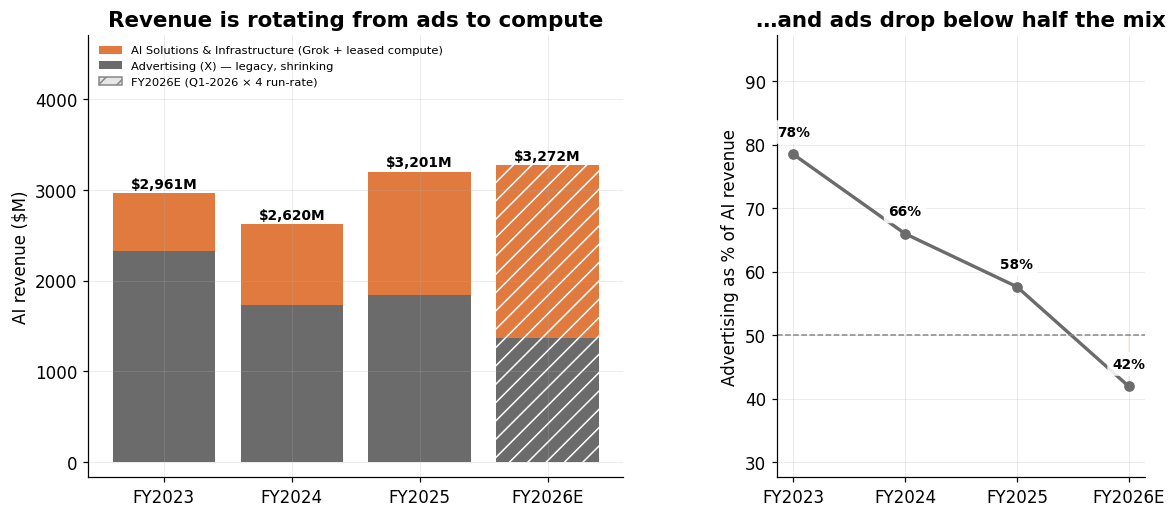

In [3]:
# Revenue mix: legacy Advertising (X) vs growth AI Solutions & Infrastructure (Grok + leased compute).
mix = pd.DataFrame({
    "Advertising (X)":                 R.advertising,
    "AI Solutions & Infrastructure":   R.ai_solutions,
})
mix["Total AI revenue"] = mix.sum(axis=1)
mix["Advertising %"]    = R.ads_pct
display(fmt(mix, pct=["Advertising %"]))      # table keeps the actual reported Q1-2026

fig, (axL, axR) = plt.subplots(1, 2, figsize=(12.4, 4.9), gridspec_kw={"width_ratios": [1.45, 1], "wspace": 0.34})

# Left: stacked revenue by source.
x = np.arange(len(CHART_PERIODS))
adv, sol = to_chart("advertising"), to_chart("ai_solutions")
b_adv = axL.bar(x, adv, color=GREY, label="Advertising (X) — legacy, shrinking")
b_sol = axL.bar(x, sol, bottom=adv, color=ORANGE, label="AI Solutions & Infrastructure (Grok + leased compute)")
for b in (b_adv, b_sol):
    b[-1].set_hatch("//"); b[-1].set_edgecolor("white"); b[-1].set_linewidth(0)
for i in range(len(CHART_PERIODS)):
    axL.text(i, adv[i] + sol[i] + 60, f"${adv[i]+sol[i]:,.0f}M", ha="center", fontsize=9, fontweight="bold")
axL.set_xticks(x); axL.set_xticklabels(CHART_PERIODS)
axL.set_ylabel("AI revenue ($M)"); axL.set_ylim(0, 4200)
axL.set_title("Revenue is rotating from ads to compute")
charts.legend_panel(axL, handles=[b_sol, b_adv, EST_PATCH], fontsize=7.5, ncol=1)

# Right: the advertising-share crossover.
ads_pct = to_chart("ads_pct")
axR.plot(x, [p * 100 for p in ads_pct], marker="o", color=GREY, lw=2.2)
axR.fill_between(x, [p * 100 for p in ads_pct], 50, where=[p < 0.5 for p in ads_pct],
                 color=ORANGE, alpha=0.12)
axR.axhline(50, color="#888", ls="--", lw=1)
for i, p in enumerate(ads_pct):
    charts.annotate_clear(axR, f"{p*100:.0f}%", (i, p*100), textcoords="offset points", xytext=(0, 12),
                 ha="center", fontsize=9, fontweight="bold")
axR.set_xticks(x); axR.set_xticklabels(CHART_PERIODS)
axR.set_ylabel("Advertising as % of AI revenue"); axR.set_ylim(30, 90)
axR.set_title("…and ads drop below half the mix")

charts.pad_ylim(axL); charts.pad_ylim(axR); charts.finish_pair(fig, wspace=0.34); charts.save(fig, "ai_revenue_mix", layout=False); plt.show()

Two businesses pointing in opposite directions are stapled together here. The **ad business is in
slow decline** — remarkable for a platform of X's reach, and a quiet admission about what the 2022
takeover did to the franchise. What's keeping the top line growing at all is **AI Solutions &
Infrastructure**, where the most interesting sub-line is *selling compute to other AI labs*: SpaceX is
becoming a **landlord for GPUs** (Anthropic among the tenants) as much as a model company. Keep that in
mind for §4 — the growth line is the one that consumes the capex.

## 2. The operating cost stack — where the GAAP loss comes from

Three operating buckets sit between revenue and the operating loss, plus lumpy restructuring:

| FY2025 | \$M |
|---|---:|
| Revenue | 3,201 |
| Cost of revenue (COGS) | (2,178) |
| Research & development | (5,064) |
| Selling, general & admin | (1,827) |
| Restructuring | (487) |
| **Income (loss) from operations** | **(6,355)** |

The shape is brutal and specific: **R&D alone (\$5,064M) is 1.6× total segment revenue**, and it grew
**27×** in two years (\$186M → \$5,064M) as xAI scaled Grok training. COGS is comparatively flat. This
is not a company with a cost-control problem; it is a company deliberately spending multiples of its
revenue to train frontier models. The waterfall on the right makes the magnitude legible.

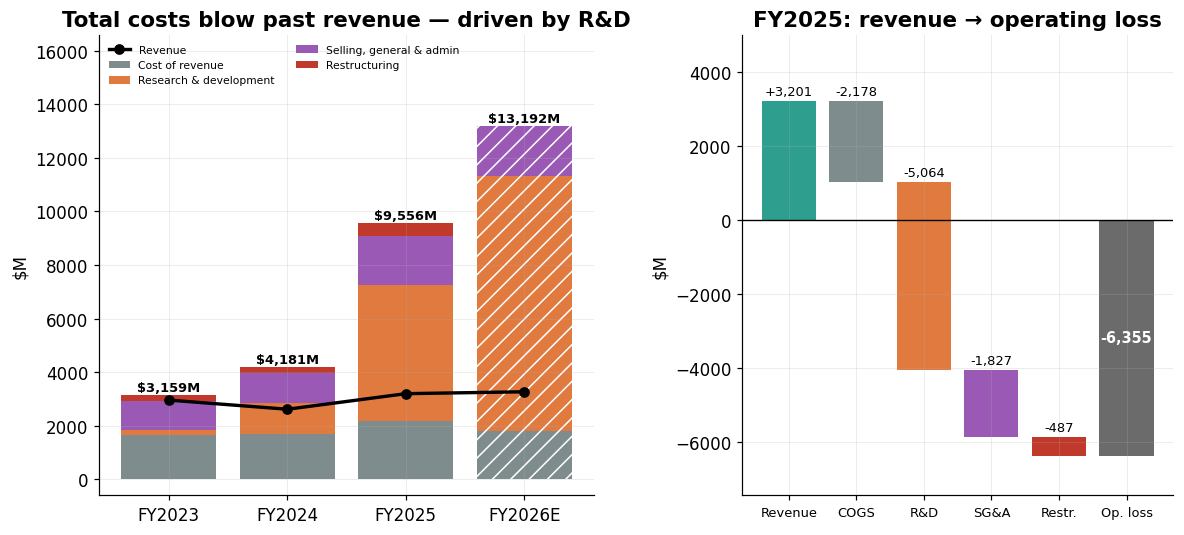

In [4]:
# Left: the cost stack vs revenue over time. Right: FY2025 revenue -> operating-loss waterfall.
fig, (axL, axR) = plt.subplots(1, 2, figsize=(12.6, 5.1), gridspec_kw={"width_ratios": [1.15, 1], "wspace": 0.32})

# --- Left: stacked operating costs, with revenue overlaid as a line ---
x = np.arange(len(CHART_PERIODS))
parts = [("cogs", "Cost of revenue", PALETTE[5]),
         ("rnd", "Research & development", ORANGE),
         ("sga", "Selling, general & admin", PALETTE[3]),
         ("restructuring", "Restructuring", PALETTE[4])]
bottom = np.zeros(len(CHART_PERIODS))
for col, lab, c in parts:
    vals = np.array(to_chart(col))
    bars = axL.bar(x, vals, bottom=bottom, color=c, label=lab)
    bars[-1].set_hatch("//"); bars[-1].set_edgecolor("white"); bars[-1].set_linewidth(0)
    bottom += vals
axL.plot(x, to_chart("revenue"), marker="o", color="black", lw=2.2, label="Revenue")
for i in range(len(CHART_PERIODS)):
    axL.text(i, bottom[i] + 150, f"${bottom[i]:,.0f}M", ha="center", fontsize=8.5, fontweight="bold")
axL.set_xticks(x); axL.set_xticklabels(CHART_PERIODS)
axL.set_ylabel("$M"); axL.set_ylim(0, 14800)
axL.set_title("Total costs blow past revenue — driven by R&D")
charts.legend_panel(axL, fontsize=7, ncol=2)

# --- Right: FY2025 waterfall ---
p = "FY2025"
steps = [("Revenue", R.revenue[p], TEAL),
         ("COGS", -R.cogs[p], PALETTE[5]),
         ("R&D", -R.rnd[p], ORANGE),
         ("SG&A", -R.sga[p], PALETTE[3]),
         ("Restr.", -R.restructuring[p], PALETTE[4])]
running = 0.0
for i, (lab, delta, c) in enumerate(steps):
    base = running if delta >= 0 else running + delta
    axR.bar(i, abs(delta), bottom=base, color=c)
    running += delta
    axR.annotate(f"{delta:+,.0f}", (i, base + abs(delta)), textcoords="offset points",
                 xytext=(0, 4), ha="center", fontsize=8.5)
axR.bar(len(steps), running, color=GREY)   # ending operating loss
axR.annotate(f"{running:,.0f}", (len(steps), running / 2), ha="center", va="center",
             fontsize=9.5, fontweight="bold", color="white")
axR.axhline(0, color="black", lw=0.9)
axR.set_xticks(range(len(steps) + 1))
axR.set_xticklabels([s[0] for s in steps] + ["Op. loss"], rotation=0, fontsize=8.5)
axR.set_ylim(-7000, 3700)
axR.set_ylabel("$M"); axR.set_title("FY2025: revenue → operating loss")

charts.pad_ylim(axL); charts.pad_ylim(axR); charts.finish_pair(fig, wspace=0.32); charts.save(fig, "ai_cost_stack", layout=False); plt.show()

The operating loss is **R&D-shaped**. Strip R&D and the segment would post a small operating profit
(\$3,201M revenue − \$2,178M COGS − \$1,827M SG&A − \$487M restructuring = **\$(1,291)M**… still a
loss once SG&A is counted, but the gap to breakeven is a fraction of the R&D line). The honest reading
is the mirror image of the Space notebook's Starship argument: there, R&D is a *capitalizable*
development invoice that converts to assets at commercialization; **here, model-training R&D is a
genuine recurring expense** that does not obviously stop. §3 looks at what is actually *in* these
buckets — because "R&D" and "COGS" for an AI lab are mostly **the same physical thing: compute**.

## 3. The *nature* of cost — compute, people, and the power bill

The S-1 reports AI cost by **P&L function** (COGS / R&D / SG&A) but **not by *nature*** (no
electricity, headcount, or hosting line for the segment). What it *does* give, segment-level, are three
cross-cutting disclosures that let us reconstruct most of the economics:

- **Depreciation & amortization — \$3,568M (FY2025).** This is the accounting echo of the server
  build-out: the boxes bought in §4 hitting the P&L a slice at a time. It is spread *across* COGS and
  R&D, and it is the single largest "nature of cost" we can see. **The capital cost of compute, not the
  electricity, is the dominant cost.**
- **Stock-based compensation — \$1,063M (FY2025).** A real (non-cash) pay expense; it 66×'d in a year
  as xAI staffed up. A visible slice of the headcount bill.
- **Electricity — *not disclosed*.** We estimate it explicitly from the one operating KPI the S-1 does
  give — **nameplate compute draw (GW)** — times an assumed utilization and \$/MWh. The result is
  *small* next to depreciation, which is the point worth saying out loud.

,Nameplate draw (GW),D&A (capital cost of compute),Stock-based comp,Est. electricity (run-rate),Elec. low–high band
period,,,,,
FY2023,0.0,"1,180",3,0,0–0
FY2024,0.3,"1,679",16,111,59–189
FY2025,0.8,"3,568","1,063",296,158–505
Q1-2026,1.0,"1,493",378,370,197–631


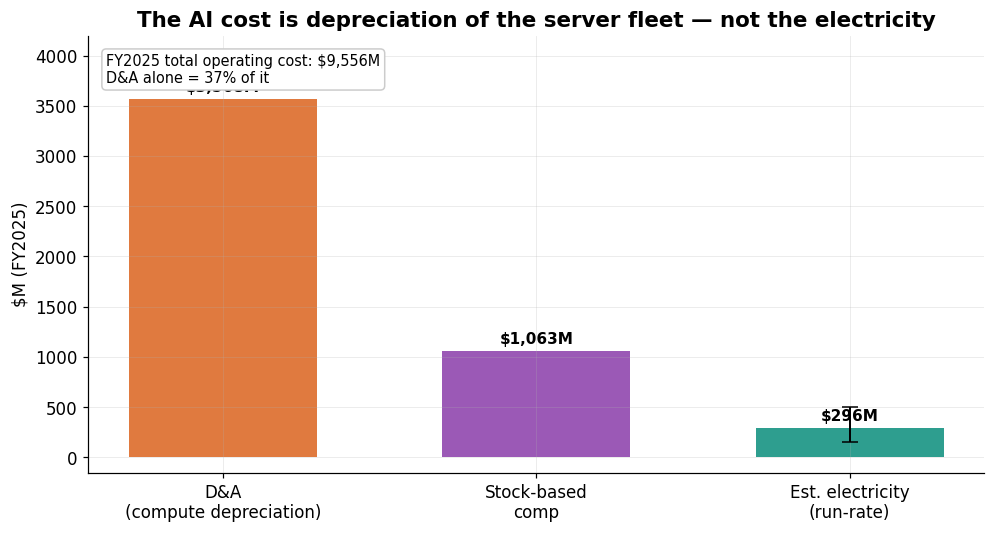

In [5]:
# Estimate the (undisclosed) power bill from nameplate GW, then compare cost "natures".
# Run-rate annual power $ at nameplate draw G (GW):  G * util * 8760h * $/MWh, with GWh->MWh (x1000).
def power_cost_m(gw, util=POWER_UTILIZATION, price=POWER_PRICE_PER_MWH):
    mwh = gw * util * HOURS_PER_YEAR * 1000.0          # GW * h -> GWh -> MWh
    return mwh * price / 1e6                            # $ -> $M

elec_base = power_cost_m(R.compute_draw_gw)             # per-period run-rate at base assumptions
elec_lo   = power_cost_m(R.compute_draw_gw, POWER_UTILIZATION_BAND[0], POWER_PRICE_BAND[0])
elec_hi   = power_cost_m(R.compute_draw_gw, POWER_UTILIZATION_BAND[1], POWER_PRICE_BAND[1])

nat = pd.DataFrame({
    "Nameplate draw (GW)":              R.compute_draw_gw,
    "D&A (capital cost of compute)":    R.da,
    "Stock-based comp":                 R.sbc,
    "Est. electricity (run-rate)":      elec_base,
    "Elec. low–high band":              [f"{lo:,.0f}–{hi:,.0f}" for lo, hi in zip(elec_lo, elec_hi)],
})
display(fmt(nat, one=["Nameplate draw (GW)"]))

# FY2025 "nature" comparison: D&A vs SBC vs estimated electricity, against the total cost base.
p = "FY2025"
labels = ["D&A\n(compute depreciation)", "Stock-based\ncomp", "Est. electricity\n(run-rate)"]
vals   = [R.da[p], R.sbc[p], elec_base[p]]
cols   = [ORANGE, PALETTE[3], TEAL]

fig, ax = plt.subplots(figsize=(9.2, 5))
bars = ax.bar(labels, vals, color=cols, width=0.6)
ax.errorbar(2, elec_base[p], yerr=[[elec_base[p]-elec_lo[p]], [elec_hi[p]-elec_base[p]]],
            fmt="none", ecolor="black", capsize=5, lw=1.3)
for b, v in zip(bars, vals):
    ax.text(b.get_x() + b.get_width()/2, v + 70, f"${v:,.0f}M", ha="center", fontsize=10, fontweight="bold")
total_cost = R.cogs[p] + R.rnd[p] + R.sga[p] + R.restructuring[p]
ax.text(0.02, 0.96, f"FY2025 total operating cost: ${total_cost:,.0f}M\n"
        f"D&A alone = {R.da[p]/total_cost:.0%} of it",
        transform=ax.transAxes, ha="left", va="top", fontsize=9.5,
        bbox=dict(boxstyle="round", fc="white", ec="#ccc"))
ax.set_ylabel("$M (FY2025)")
ax.set_title("The AI cost is depreciation of the server fleet — not the electricity")
charts.pad_ylim(ax); charts.finish(fig); charts.save(fig, "ai_cost_nature", layout=False); plt.show()

The popular story about AI cost is the **power bill**. As a *dollar operating cost* in this filing it
isn't — at least not yet. At ~1 GW of nameplate draw, an honest run-rate electricity estimate lands
around **\$0.3–0.4B/yr** (band roughly \$0.2–0.6B under wide utilization/price assumptions), versus
**\$3,568M of D&A**. The cost that matters today is the **depreciation of a server fleet bought faster
than it can be loaded** — D&A is ~30% of the entire operating cost base, and it is *growing* as the
capex in §4 piles up. Today the meter running fastest is the **balance sheet**, not the grid.

But hold that thought: a small *electricity bill* and a binding *power constraint* are different things.
Electricity is cheap; **gigawatts of interconnect are not, and they gate everything** — fleet size,
the obsolescence treadmill, and the revenue ceiling. §5 picks that up directly.

*(Caveat: the electricity figure is a run-rate at period-end nameplate draw, not the realized annual
bill during a ramp, and it excludes power that may be embedded in third-party hosting inside COGS. It
sizes the line; it does not reconcile to a disclosed figure — because none exists.)*

## 4. Capex & the physical build-out — \$12.7B at ~4× revenue

The D&A in §3 has a cause: an extraordinary capital-spending ramp. AI-segment capex went
**\$463M → \$5,633M → \$12,727M** (FY2023–25), and **\$7,723M in Q1-2026 alone**. At FY2025 that is
**~4× the segment's own revenue** — a ratio you essentially never see outside a utility or a telco
laying its first network. The cash isn't vanishing; it is landing on the consolidated balance sheet as
PP&E. Note 5 lets us see *where*: **Servers & networking equipment** more than **tripled** (\$6.9B →
\$22.7B) and **Data-center infrastructure** went \$0.2B → \$3.0B in a single year.

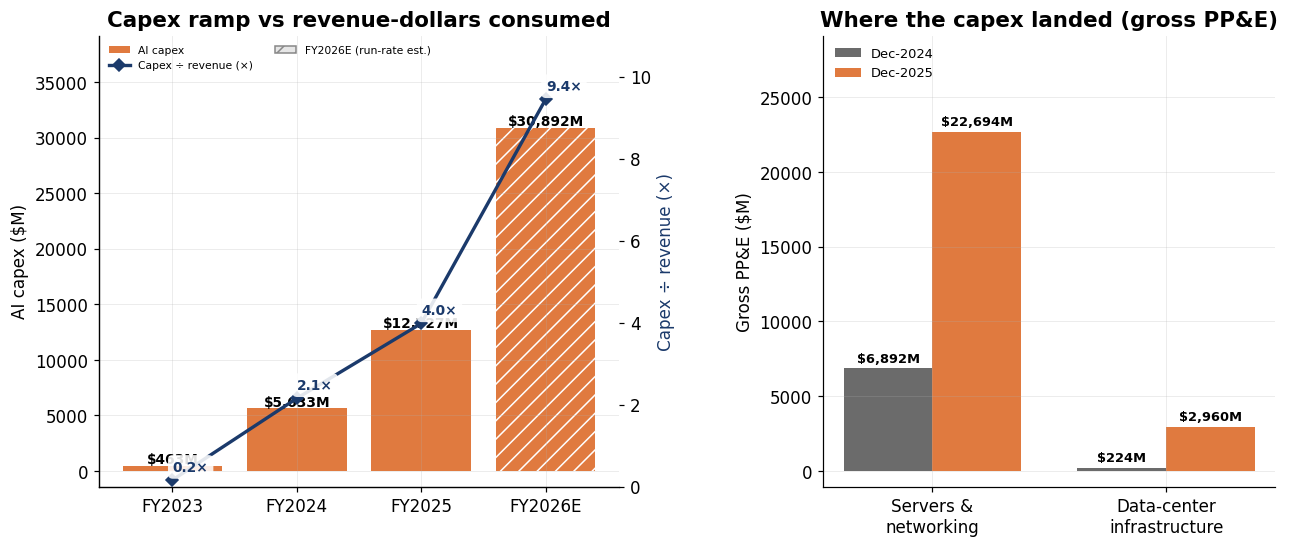

In [6]:
# Left: capex over time + capex/revenue intensity. Right: where it landed in PP&E (Note 5).
fig, (axL, axR) = plt.subplots(1, 2, figsize=(13.8, 5.0),
                               gridspec_kw={"width_ratios": [1.15, 1], "wspace": 0.42})

# --- Left: capex bars + capex/revenue ratio on a twin axis ---
x = np.arange(len(CHART_PERIODS))
cap = to_chart("capex")
bars = axL.bar(x, cap, color=ORANGE, label="AI capex")
bars[-1].set_hatch("//"); bars[-1].set_edgecolor("white"); bars[-1].set_linewidth(0)
for i, v in enumerate(cap):
    axL.text(i, v + 180, f"${v:,.0f}M", ha="center", fontsize=9, fontweight="bold")
axL.set_xticks(x); axL.set_xticklabels(CHART_PERIODS)
axL.set_ylabel("AI capex ($M)"); axL.set_ylim(0, 35000)
axL.set_title("Capex ramp vs revenue-dollars consumed")

ax2 = axL.twinx()
ratio = np.array(cap) / np.array(to_chart("revenue"))
ax2.plot(x, ratio, marker="D", color=NAVY, lw=2.2, label="Capex ÷ revenue (×)")
for i, r in enumerate(ratio):
    charts.annotate_clear(ax2, f"{r:.1f}×", (i, r), textcoords="offset points", xytext=(12, 6),
                 ha="center", fontsize=9, color=NAVY, fontweight="bold")
ax2.set_ylabel("Capex ÷ revenue (×)", color=NAVY); ax2.set_ylim(0, 11); ax2.grid(False)
h1, l1 = axL.get_legend_handles_labels(); h2, l2 = ax2.get_legend_handles_labels()
charts.legend_twin_panel(axL, ax2, handles=h1 + h2 + [EST_PATCH], labels=l1 + l2 + ["FY2026E (run-rate est.)"], fontsize=7, ncol=2)

# --- Right: PP&E composition jump, 2024 -> 2025 (Note 5) ---
ppe = AIModel().ppe_ai()[["2024-12-31", "2025-12-31"]]
comps = ["Servers and networking equipment", "Data center infrastructure"]
xc = np.arange(len(comps)); w = 0.38
axR.bar(xc - w/2, ppe.loc[comps, "2024-12-31"], w, color=GREY, label="Dec-2024")
axR.bar(xc + w/2, ppe.loc[comps, "2025-12-31"], w, color=ORANGE, label="Dec-2025")
for i, comp in enumerate(comps):
    for off, d in [(-w/2, "2024-12-31"), (w/2, "2025-12-31")]:
        v = ppe.loc[comp, d]
        axR.text(i + off, v + 400, f"${v:,.0f}M", ha="center", fontsize=8.5, fontweight="bold")
axR.set_xticks(xc); axR.set_xticklabels(["Servers &\nnetworking", "Data-center\ninfrastructure"])
axR.set_ylabel("Gross PP&E ($M)"); axR.set_ylim(0, 26000)
axR.set_title("Where the capex landed (gross PP&E)")
charts.legend_panel(axR, fontsize=8.5)

charts.pad_ylim(axL); charts.pad_ylim(axR); charts.finish_pair(fig, wspace=0.38); charts.save(fig, "ai_capex_buildout", layout=False); plt.show()

This is the part of the S-1 that should reframe how you read the whole filing. SpaceX is not just a
rocket company with a model team bolted on; it is, by capital deployed, **building one of the largest
private compute fleets in the world** — and partly *renting it out* (the Anthropic line in §1). The
capex-to-revenue ratio of ~4× tells you the revenue hasn't caught up to the iron, which is exactly what
drives the §3 depreciation and the §5 EBITDA collapse. The forward question the next notebook must
answer: **at what utilization and price does this fleet's revenue overtake its depreciation?** Today it
does not.

> **Forward note — will the build keep growing? That's a *financing* question, not a demand one.** This
> section is historical, but it begs the obvious forward question, and it's worth flagging here before the
> scenario work: the \$12.7B FY2025 capex became **~\$7.7B in Q1-2026 alone — a ~\$31B annual run-rate,
> roughly doubling year over year.** Nothing in operations pays for that: the segment loses money, so the
> build is funded by **external capital** (in FY2025, \$18.8B of fresh equity + \$16.1B of new debt at the
> *company* level). That makes "does compute keep growing?" equivalent to **"does the capital tap stay
> open?"** — and it cuts both ways. If markets stay open, the run-rate can keep climbing; if they tighten
> (a soft IPO, dilution fatigue, higher rates), capex **caps itself**, the fleet stops growing, and the
> depreciation that dominates this segment's cost stops climbing with it — a *self-limiting* furnace rather
> than a runaway one. The flip side is that the same throttle caps the upside: a capital-constrained xAI
> never gets the fleet big enough to clear its own depreciation (§5). We make this quantitative in the
> integrated notebook (§8, "Can they even afford the build?"), where capex is inverted onto a financing
> ceiling and the gigawatt path becomes an *output* of how much SpaceX can raise — gated, above all, by how
> much cash Starlink throws off.

## 5. The chips beneath the depreciation

Section 3 showed the AI cost is *depreciation*, and §4 showed it is a \$25.7B pile of **servers &
networking**. So the real questions are physical: **how many AI chips is this, what are they, and can
they earn their cost back before they're obsolete?** The S-1 never says "GPU" — but it hands us two
hard anchors to triangulate from: the **1.0 GW nameplate compute draw** and the **\$22.7B** gross
"Servers and networking equipment" balance (Note 5). Cross them with public NVIDIA platform specs
(power per GPU, system cost per GPU) and the fleet size falls out two independent ways.

The stakes: a GPU is a *depreciating, obsolescing* asset. If its real economic life is long — it keeps
earning (Grok inference, leased capacity to the likes of Anthropic) for years after it's booked down —
then today's depreciation *overstates* the true cost and the segment is fine. But if NVIDIA's now-annual
cadence makes each generation economically stale in ~3 years, and SpaceX must keep re-buying just to
stay competitive while rental prices fall, then the capital never comes back and this segment is a
**treadmill**. The whole AI valuation hinges on which of those is true.

,low (k),base (k),high (k)
Power method (1.0 GW),500.0,571.4,625.0
Dollar method ($22.7B servers),540.3,630.4,709.2


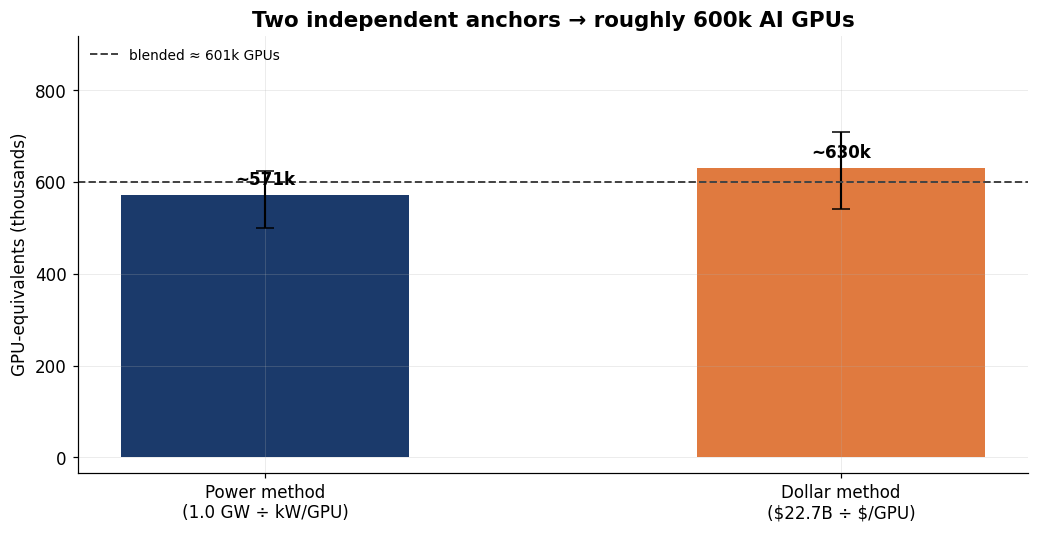

In [7]:
# Triangulate the fleet size from the two S-1 anchors x public NVIDIA platform specs.
from analysis.ai_economics import (GPU_SPECS, FLEET_ALL_IN_KW, FLEET_SYSTEM_USD_K,
    USEFUL_LIFE_ACCOUNTING, USEFUL_LIFE_BAND, SALVAGE_FRACTION,
    WACC_ASSUMED, GPU_RENTAL_USD_HR, GPU_RENTAL_USD_HR_BAND)

gw      = R.compute_draw_gw["Q1-2026"]                                       # 1.0 GW nameplate (latest)
ai_ppe  = AIModel().ppe_ai()
servers = ai_ppe.loc["Servers and networking equipment", "2025-12-31"]      # $22,694M gross

kw_lo,  kw_hi  = min(s["all_in_kw"]   for s in GPU_SPECS.values()), max(s["all_in_kw"]   for s in GPU_SPECS.values())
sys_lo, sys_hi = min(s["system_usd_k"] for s in GPU_SPECS.values()), max(s["system_usd_k"] for s in GPU_SPECS.values())

# Method 1 - power:   GPUs = nameplate kW / per-GPU all-in kW   (more power/GPU -> fewer GPUs)
p_base, p_min, p_max = gw*1e6/FLEET_ALL_IN_KW, gw*1e6/kw_hi, gw*1e6/kw_lo
# Method 2 - dollars: GPUs = servers$k / per-GPU system$k       ($M*1e3 = $k)
d_base, d_min, d_max = servers*1e3/FLEET_SYSTEM_USD_K, servers*1e3/sys_hi, servers*1e3/sys_lo
blended = (p_base + d_base) / 2

count = pd.DataFrame({"low (k)": [p_min, d_min], "base (k)": [p_base, d_base], "high (k)": [p_max, d_max]},
                     index=[f"Power method ({gw:.1f} GW)", f"Dollar method (${servers/1e3:.1f}B servers)"]) / 1e3
display(fmt(count, one=list(count.columns)))

fig, ax = plt.subplots(figsize=(9.6, 5))
xs = np.arange(2)
mids = np.array([p_base, d_base]) / 1e3
lo   = mids - np.array([p_min, d_min]) / 1e3
hi   = np.array([p_max, d_max]) / 1e3 - mids
bars = ax.bar(xs, mids, width=0.5, color=[NAVY, ORANGE])
ax.errorbar(xs, mids, yerr=[lo, hi], fmt="none", ecolor="black", capsize=6, lw=1.4)
for x, m in zip(xs, mids):
    ax.text(x, m + 22, f"~{m:,.0f}k", ha="center", fontsize=11, fontweight="bold")
ax.axhline(blended/1e3, color="#444", ls="--", lw=1.3,
           label=f"blended ≈ {blended/1e3:,.0f}k GPUs")
ax.set_xticks(xs)
ax.set_xticklabels(["Power method\n(1.0 GW ÷ kW/GPU)", "Dollar method\n(\\$22.7B ÷ \\$/GPU)"])
ax.set_ylabel("GPU-equivalents (thousands)"); ax.set_ylim(0, 820)
ax.set_title("Two independent anchors → roughly 600k AI GPUs")
charts.pad_ylim(ax); charts.legend_panel(ax, fontsize=9); charts.finish(fig); charts.save(fig, "ai_gpu_count", layout=False); plt.show()

**~600,000 GPU-equivalents**, and the two methods agree to within a rounding error — a strong sign the
spec assumptions aren't crazy. For scale, that is on the order of *all* the H100s NVIDIA shipped to its
largest single customers in a year, sitting inside one segment of one filing.

**What are they?** The S-1 won't say, but the capex *timing* does the dating for us. The 2024 build
(\$5.6B capex) lands squarely in the **Hopper** era — H100 / H200. The 2025 doubling (\$12.7B) and the
\$7.7B *single quarter* in Q1-2026 line up with the **Blackwell** ramp — B200 / GB200 NVL72 racks. So
the fleet is almost certainly a **Hopper core being rapidly overbuilt with Blackwell** — which is
exactly the setup that makes the obsolescence question below sharp: the newest, most expensive chips
are arriving just as the prior generation starts aging.

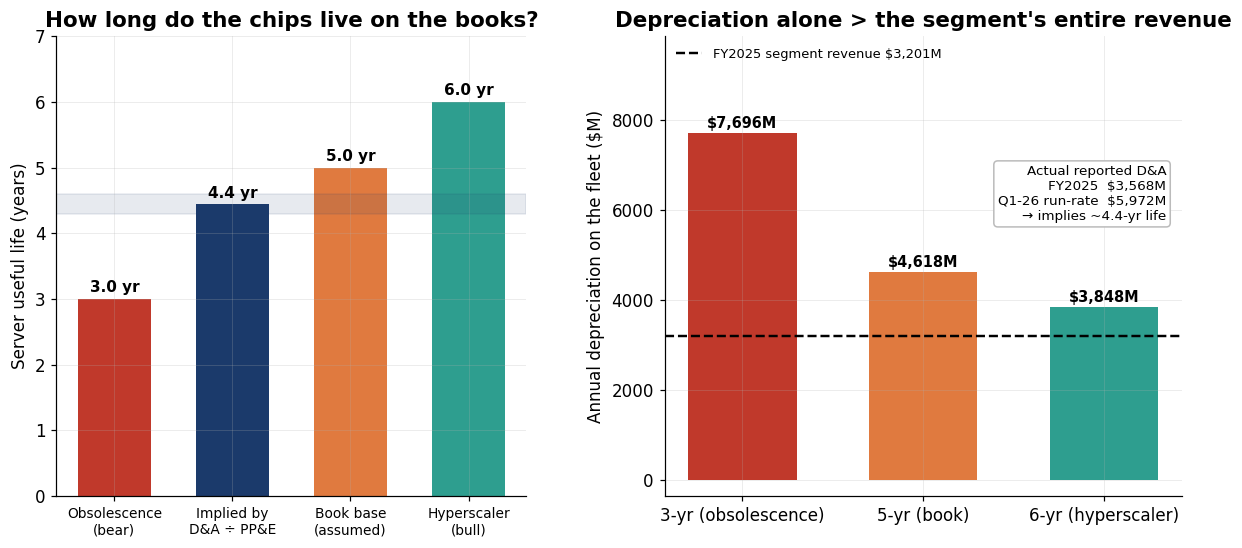

In [8]:
# Left: useful life - implied-from-data vs the assumption band. Right: depreciation vs revenue.
gross_24 = ai_ppe["2024-12-31"].sum()          # servers+networking + data-center infra, gross
gross_25 = ai_ppe["2025-12-31"].sum()
da_25    = R.da["FY2025"]                        # AI segment D&A (servers dominate)
da_run   = R.da["Q1-2026"] * 4                   # exit run-rate (Q1-2026 annualized)
life_avg = (gross_24 + gross_25) / 2 / da_25     # implied life on average gross base
life_exit = gross_25 / da_run                    # implied life on year-end base, exit run-rate

fig, (axL, axR) = plt.subplots(1, 2, figsize=(13.2, 5.1), gridspec_kw={"width_ratios": [1, 1.1], "wspace": 0.28})

# --- Left: useful-life scenarios, with the data-implied range shaded ---
lives = {"Obsolescence\n(bear)": USEFUL_LIFE_BAND[0], "Implied by\nD&A ÷ PP&E": (life_avg + life_exit) / 2,
         "Book base\n(assumed)": USEFUL_LIFE_ACCOUNTING, "Hyperscaler\n(bull)": USEFUL_LIFE_BAND[1]}
cols = [PALETTE[4], NAVY, ORANGE, TEAL]
axL.bar(range(len(lives)), list(lives.values()), color=cols, width=0.62)
for i, (k, v) in enumerate(lives.items()):
    axL.text(i, v + 0.1, f"{v:.1f} yr", ha="center", fontsize=10, fontweight="bold")
axL.axhspan(life_exit, life_avg, color=NAVY, alpha=0.10)
axL.set_xticks(range(len(lives))); axL.set_xticklabels(list(lives.keys()), fontsize=9)
axL.set_ylabel("Server useful life (years)"); axL.set_ylim(0, 7)
axL.set_title("How long do the chips live on the books?")

# --- Right: annual depreciation on the $25.7B installed base vs segment revenue ---
life_scen = [("3-yr (obsolescence)", 3.0, PALETTE[4]), ("5-yr (book)", 5.0, ORANGE), ("6-yr (hyperscaler)", 6.0, TEAL)]
dep = [gross_25 * (1 - SALVAGE_FRACTION) / L for _, L, _ in life_scen]
xs = np.arange(len(life_scen))
axR.bar(xs, dep, color=[c for *_, c in life_scen], width=0.6)
for x, dval in zip(xs, dep):
    axR.text(x, dval + 120, f"\\${dval:,.0f}M", ha="center", fontsize=9.5, fontweight="bold")
axR.axhline(R.revenue["FY2025"], color="black", lw=1.6, ls="--",
           label=f"FY2025 segment revenue ${R.revenue['FY2025']:,.0f}M")
charts.legend_panel(axR, fontsize=8.5)
axR.text(0.97, 0.72,
         f"Actual reported D&A\nFY2025  \\${da_25:,.0f}M\nQ1-26 run-rate  \\${da_run:,.0f}M\n→ implies ~{(life_avg+life_exit)/2:.1f}-yr life",
         transform=axR.transAxes, ha="right", va="top", fontsize=8.8,
         bbox=dict(boxstyle="round", fc="white", ec="#bbb"))
axR.set_xticks(xs); axR.set_xticklabels([s for s, *_ in life_scen])
axR.set_ylabel("Annual depreciation on the fleet (\\$M)"); axR.set_ylim(0, 8800)
axR.set_title("Depreciation alone > the segment's entire revenue")
charts.pad_ylim(axR); charts.finish_pair(fig, wspace=0.30); charts.save(fig, "ai_gpu_depreciation", layout=False); plt.show()

This is where depreciation **stops being a footnote and becomes the business**. The fleet's
depreciation under *any* plausible life — \$3.8B at a generous 6 years, \$7.7B at a bearish 3 — is
**larger than the segment's entire FY2025 revenue of \$3,201M**. The actual reported D&A (\$3,568M, and
a \$5,972M Q1-2026 run-rate) implies a book life of **~4.3–4.6 years** — i.e. SpaceX is depreciating
these chips roughly like a hyperscaler, *not* like someone bracing for 3-year obsolescence.

That is the optimistic accounting choice, and it cuts both ways. If the chips really do earn for ~5
years, the books are honest. If Blackwell makes Hopper economically stale in 3, then reported
depreciation **understates** the true cost of staying current — the P&L looks better than the cash
reality, and the gap is hidden in a longer assumed life.

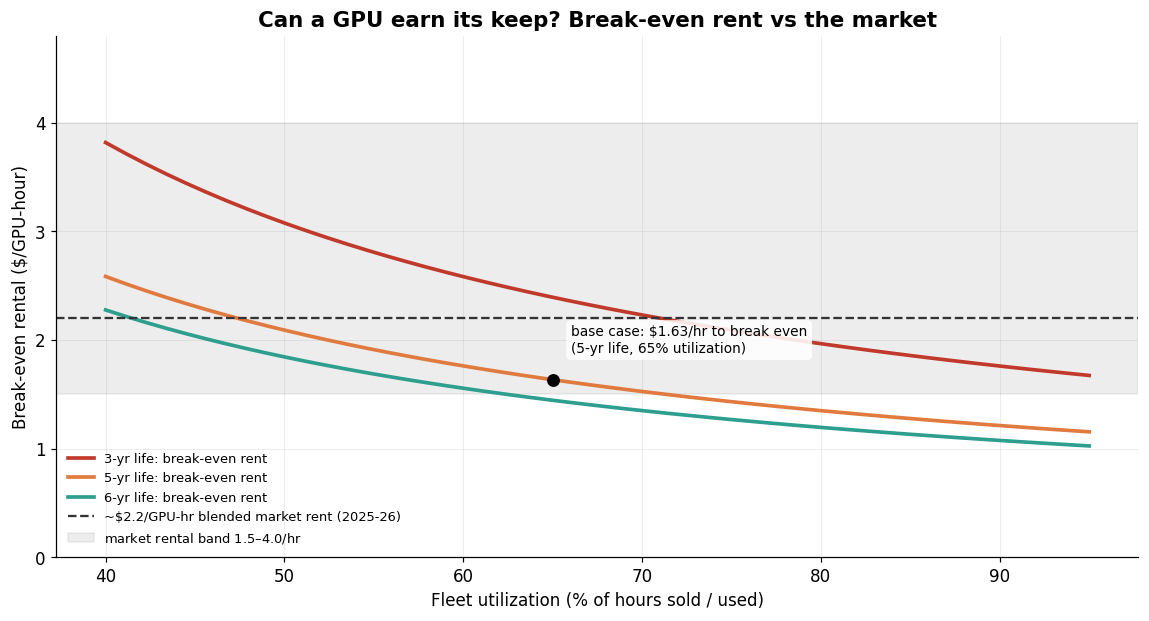

Per-GPU annual cost @ 5-yr life, 65% util ($):
  depreciation 6,480 | power 648 | capital charge 2,178 | total 9,306


In [9]:
# The treadmill test: what must a GPU earn per hour to cover its own cost, vs what the market pays?
def gpu_costs(system_k, life_yr, util, power_price=POWER_PRICE_PER_MWH, wacc=WACC_ASSUMED):
    dep     = system_k * 1e3 * (1 - SALVAGE_FRACTION) / life_yr          # $/yr straight-line
    power   = FLEET_ALL_IN_KW * 8760 * util * power_price / 1e3          # $/yr at this utilization
    capital = wacc * 0.55 * system_k * 1e3                               # cost of capital on avg book value
    return dep, power, capital

def breakeven_hr(system_k, life_yr, util, **kw):
    return sum(gpu_costs(system_k, life_yr, util, **kw)) / (util * 8760)  # $/productive GPU-hour

utils = np.linspace(0.40, 0.95, 50)
fig, ax = plt.subplots(figsize=(10.6, 5.8))
for life, c in [(3.0, PALETTE[4]), (5.0, ORANGE), (6.0, TEAL)]:
    be = [breakeven_hr(FLEET_SYSTEM_USD_K, life, u) for u in utils]
    ax.plot(utils * 100, be, color=c, lw=2.4, label=f"{life:.0f}-yr life: break-even rent")

ax.axhline(GPU_RENTAL_USD_HR, color="#333", ls="--", lw=1.5,
           label=f"~${GPU_RENTAL_USD_HR}/GPU-hr blended market rent (2025-26)")
ax.axhspan(*GPU_RENTAL_USD_HR_BAND, color=GREY, alpha=0.12, label="market rental band $1.5–$4.0/hr")

# Base-case marker (5-yr life, 65% utilization).
u0 = 0.65; be0 = breakeven_hr(FLEET_SYSTEM_USD_K, 5.0, u0)
ax.scatter([u0 * 100], [be0], color="black", zorder=6, s=55)
charts.annotate_clear(ax, f"base case: ${be0:.2f}/hr to break even\n(5-yr life, {u0:.0%} utilization)",
            (u0 * 100, be0), textcoords="offset points", xytext=(12, 18), fontsize=9)

ax.set_xlabel("Fleet utilization (% of hours sold / used)")
ax.set_ylabel("Break-even rental ($/GPU-hour)"); ax.set_ylim(0, 4.8)
ax.set_title("Can a GPU earn its keep? Break-even rent vs the market")
# curves stack the top-left; legend in the open lower-left
charts.legend_panel(ax, fontsize=8.5, ncol=1, loc="lower left")
charts.finish(fig); charts.save(fig, "ai_gpu_treadmill", layout=False); plt.show()

print("Per-GPU annual cost @ 5-yr life, 65% util ($):")
d, p, c = gpu_costs(FLEET_SYSTEM_USD_K, 5.0, 0.65)
print(f"  depreciation {d:,.0f} | power {p:,.0f} | capital charge {c:,.0f} | total {d+p+c:,.0f}")

**Read the chart as the whole AI thesis in one frame.** To cover its own depreciation, power, and cost
of capital, each GPU has to earn roughly **\$1.4–\$2.4 per productive hour**, depending on how long the
chip really lives and how full the fleet runs. The market rental rate for H100-class compute has fallen
from ~\$4/hr (2023) toward **~\$2/hr and below** (2025–26) and keeps dropping as supply floods in. So the
segment lives in a narrow, closing gap:

- **Utilization is oxygen.** At 90% the break-even drops under \$1.50/hr (comfortably profitable); at
  40% it blows past \$2.50/hr (underwater). Empty GPUs depreciate just as fast as busy ones — which is
  why *leasing capacity to Anthropic and others* (§1) isn't a side hustle, it's survival: it's how you
  keep utilization up when your own Grok demand can't fill a 1 GW fleet.
- **Useful life is the swing factor.** On a 5–6-year life the fleet clears today's ~\$2 market. On a
  3-year obsolescence life it does **not** — break-even sits above the market and every chip loses
  money over its life.

**Do the chips stay valuable past their booked life?** Partly — and it's the bull case. Older GPUs have
historically kept earning (A100s were still renting profitably years after launch), so a long economic
tail would mean today's depreciation *overstates* the real cost. But the tail is compressing: NVIDIA
went to an **annual** cadence (Hopper → Blackwell → Rubin) and each step is a big perf-per-dollar and,
crucially, perf-per-**watt** jump.

### Power is the bottleneck, not the electricity bill

This is the reconciliation with §3, where power looked *cheap* (~\$0.3B/yr). Both are true, because power
plays two different roles. As an **operating expense** it's minor. As a **physical constraint** it is the
whole game:

- **It caps the fleet.** A ~1 GW grid connection is what fits ~600k GPUs (§5.1). You cannot add useful
  compute beyond the power you can actually secure and interconnect — and hundreds of MW of new capacity
  take *years* to energize. Power, not capital or even chip supply, is the gating resource.
- **It drives the treadmill.** Obsolescence here isn't chips breaking — it's that a fixed 1 GW site hosts
  far more *useful* compute when last-gen silicon is swapped for new. The old chips get **evicted to free
  up watts**, regardless of whether they still run. That, not failure, is what forces the rebuy.
- **It ceilings revenue.** Revenue is bounded by useful compute sold, which is bounded by power. The
  segment's revenue ceiling is ultimately **how many gigawatts SpaceX can plug in** — which is exactly
  why nameplate-GW, not a dollar figure, is the one operating KPI the S-1 chose to disclose for AI.

### What the market actually pays: rental rates, current and historical

The treadmill chart above compares break-even to "the market rate", so here is the market evidence
behind that line. **EXTERNAL data** (not from the S-1): `csv/gpu_rental_rates.csv`, date-stamped and
source-flagged like the other quarantined files. Two views: the H100's rental price through time
(the same chip, repriced as supply flooded in), and the current cross-provider median by chip
generation (what age does to a GPU's earning power).

<>:28: SyntaxWarning: "\$" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\$"? A raw string is also an option.
<>:37: SyntaxWarning: "\$" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\$"? A raw string is also an option.
<>:28: SyntaxWarning: "\$" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\$"? A raw string is also an option.
<>:37: SyntaxWarning: "\$" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\$"? A raw string is also an option.
/var/folders/wm/gm9z3b_j4cjb_n2bg_3ydpy80000gn/T/ipykernel_6679/637938207.py:28: SyntaxWarning: "\$" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\$"? A raw string is also an option.
  ax.set_title("The H100: \$8/hr (2023) -> ~\$2/hr (2025-26)")
/var/folders/wm/gm9z3b_j4cjb_n2bg_3ydpy80000gn/T/ipykernel_6679/637938207.py:37: SyntaxWarnin

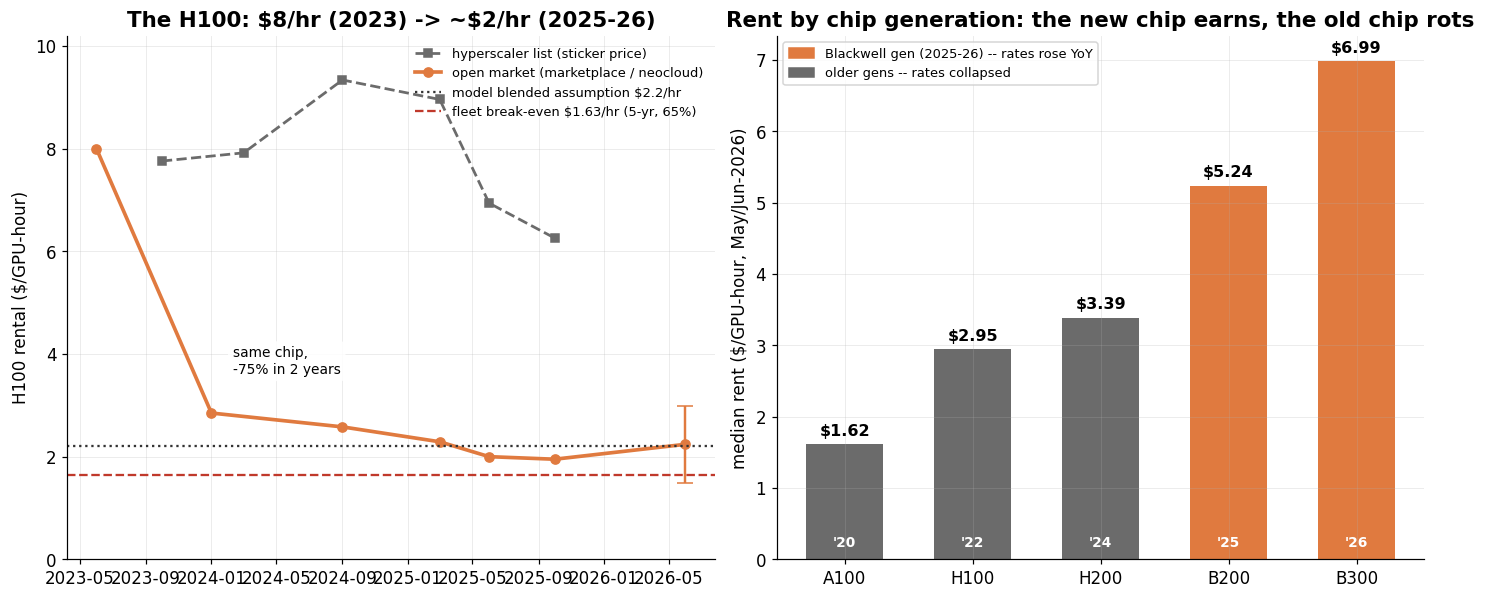

H100 open-market: $8.00 (2023 peak) -> $2.24 (Jun-2026 band $1.49-2.99) = -72%
Newest chip (B300 $6.99) rents at 4.3x the 2020 chip (A100 $1.62).


In [10]:
# EXTERNAL (csv/gpu_rental_rates.csv): what renting a GPU costs -- through time, and by chip age.
rent  = pd.read_csv(os.path.join(_p, "csv", "gpu_rental_rates.csv"))
mkt   = rent[rent.series == "h100_marketplace"].copy()
hyp   = rent[rent.series == "h100_hyperscaler"].copy()
chips = rent[rent.series == "current_by_chip"].sort_values("launch_year").copy()
for df in (mkt, hyp): df["t"] = pd.to_datetime(df["date"])

fig, axes = plt.subplots(1, 2, figsize=(13.2, 5.6))

# -- Left: the H100 through time. The chip didn't change; the supply did.
ax = axes[0]
ax.plot(hyp.t, hyp.usd_per_hr, "s--", color=GREY, lw=1.8, ms=5,
        label="hyperscaler list (sticker price)")
ax.plot(mkt.t, mkt.usd_per_hr, "o-", color=ORANGE, lw=2.4, ms=6,
        label="open market (marketplace / neocloud)")
last = mkt.iloc[-1]
ax.errorbar([last.t], [last.usd_per_hr],
            yerr=[[last.usd_per_hr - last.usd_per_hr_low], [last.usd_per_hr_high - last.usd_per_hr]],
            fmt="none", ecolor=ORANGE, capsize=5, lw=1.6)
ax.axhline(GPU_RENTAL_USD_HR, color="#333", ls=":", lw=1.5,
           label=f"model blended assumption ${GPU_RENTAL_USD_HR}/hr")
be0 = breakeven_hr(FLEET_SYSTEM_USD_K, 5.0, 0.65)
ax.axhline(be0, color=PALETTE[4], ls="--", lw=1.5,
           label=f"fleet break-even ${be0:.2f}/hr (5-yr, 65%)")
charts.annotate_clear(ax, "same chip,\n-75% in 2 years", (mkt.t.iloc[1], mkt.usd_per_hr.iloc[1]),
                      textcoords="offset points", xytext=(14, 26), fontsize=9)
ax.set_ylabel("H100 rental ($/GPU-hour)"); ax.set_ylim(0, 10.2)
ax.set_title("The H100: \$8/hr (2023) -> ~\$2/hr (2025-26)")
charts.legend_panel(ax, fontsize=8.5, loc="upper right")

# -- Right: Jun-2026 median rent by chip generation -- age rots the rate.
ax = axes[1]
xs = np.arange(len(chips))
cols = [GREY if y < 2025 else ORANGE for y in chips.launch_year]
bars = ax.bar(xs, chips.usd_per_hr, width=0.6, color=cols)
for x, (v, y) in enumerate(zip(chips.usd_per_hr, chips.launch_year)):
    ax.text(x, v + 0.12, f"\${v:.2f}", ha="center", fontsize=10.5, fontweight="bold")
    ax.text(x, 0.18, f"'{str(int(y))[2:]}", ha="center", fontsize=9, color="white", fontweight="bold")
ax.set_xticks(xs); ax.set_xticklabels(chips.gpu)
ax.set_ylabel("median rent ($/GPU-hour, May/Jun-2026)")
ax.set_title("Rent by chip generation: the new chip earns, the old chip rots")
ax.legend(handles=[Patch(color=ORANGE, label="Blackwell gen (2025-26) -- rates rose YoY"),
                   Patch(color=GREY,   label="older gens -- rates collapsed")],
          fontsize=8.5, loc="upper left", frameon=True)
charts.finish(fig); charts.save(fig, "ai_gpu_rental_market", layout=False); plt.show()

drop = 1 - mkt.usd_per_hr.iloc[-1] / mkt.usd_per_hr.iloc[0]
ratio = chips.usd_per_hr.max() / chips.usd_per_hr.min()
print(f"H100 open-market: ${mkt.usd_per_hr.iloc[0]:.2f} (2023 peak) -> ${mkt.usd_per_hr.iloc[-1]:.2f} "
      f"(Jun-2026 band ${last.usd_per_hr_low:.2f}-{last.usd_per_hr_high:.2f}) = -{drop:.0%}")
print(f"Newest chip (B300 ${chips.usd_per_hr.max():.2f}) rents at {ratio:.1f}x the 2020 chip "
      f"(A100 ${chips.usd_per_hr.min():.2f}).")

**Both panels are the same fact seen twice.** A *chip generation's* rent only goes one way: the H100
rented for ~\$8/hr at the 2023 peak, ~\$2.85 by early 2024, and ~\$2 from mid-2025 on (a ~70%+ collapse),
while hyperscaler *list* prices stayed 3x higher than the street. Meanwhile the *newest* chip always
rents high — B200/B300 at \$5–7/hr, up year-over-year — which is precisely why the treadmill never
stops: the fleet's revenue rate decays toward the A100's \$1.62 unless SpaceX keeps re-buying the new
generation. The model's blended \$2.2/hr sits where the open-market H100 actually trades, just above
the \$1.63 break-even. The bull case below is, concretely, a bet that the orange line on the left turns
back up — or that the fleet stays perpetually young on the right panel, which costs ~\$30B+ a year.

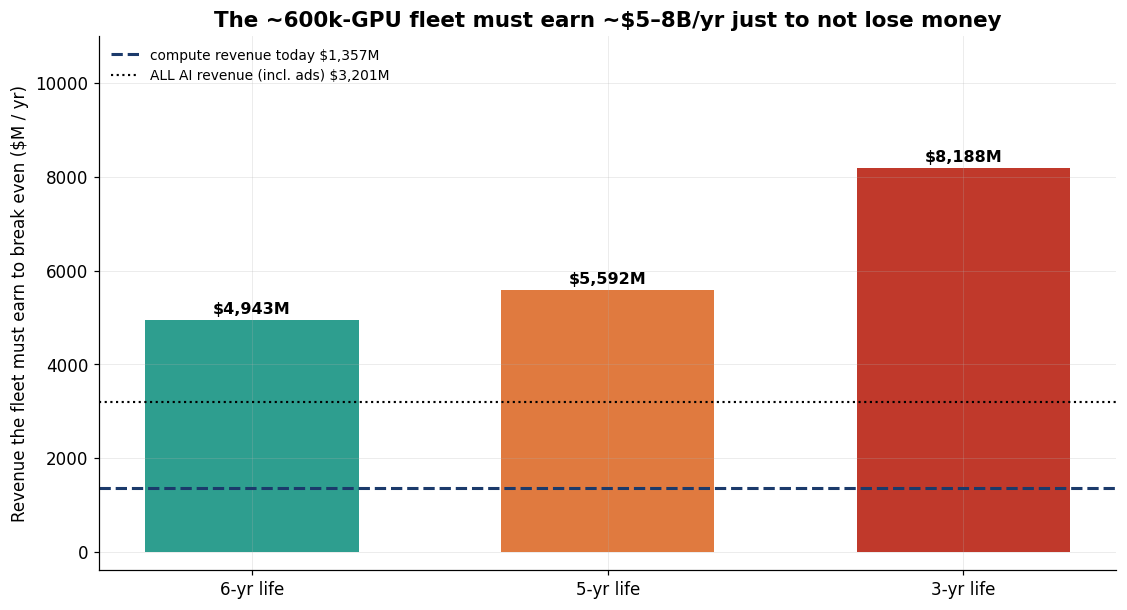

At 65% utilization, 5-yr life: fleet must earn $5,592M/yr to break even.
It monetizes compute at $1,357M/yr today -> the compute line must grow ~4.1x.
Even ALL AI revenue ($3,201M, incl. ads) is below the 5-yr break-even.


In [11]:
# Make the break-even concrete in TOTAL dollars: what must the whole ~600k-GPU fleet earn each year?
fleet = blended                                  # ~601k GPU-equivalents (from the §5.1 triangulation)
util0 = 0.65
lives = [(6.0, TEAL), (5.0, ORANGE), (3.0, PALETTE[4])]
need  = {L: fleet * sum(gpu_costs(FLEET_SYSTEM_USD_K, L, util0)) / 1e6 for L, _ in lives}   # $M/yr

fig, ax = plt.subplots(figsize=(10.4, 5.7))
labels = [f"{int(L)}-yr life" for L, _ in lives]
vals   = [need[L] for L, _ in lives]
bars = ax.bar(labels, vals, color=[c for _, c in lives], width=0.6)
for b, v in zip(bars, vals):
    ax.text(b.get_x() + b.get_width()/2, v + 130, f"\\${v:,.0f}M", ha="center", fontsize=10.5, fontweight="bold")

sol = R.ai_solutions["FY2025"]; tot = R.revenue["FY2025"]
ax.axhline(sol, color=NAVY, lw=2.0, ls="--", label=f"compute revenue today ${sol:,.0f}M")
ax.axhline(tot, color="black", lw=1.4, ls=":", label=f"ALL AI revenue (incl. ads) ${tot:,.0f}M")
ax.set_ylabel("Revenue the fleet must earn to break even (\\$M / yr)")
ax.set_ylim(0, max(vals) * 1.2)
ax.set_title("The ~600k-GPU fleet must earn ~\\$5–8B/yr just to not lose money")
charts.pad_ylim(ax); charts.legend_panel(ax, fontsize=9); charts.finish(fig); charts.save(fig, "ai_fleet_revenue_need", layout=False); plt.show()

print(f"At {util0:.0%} utilization, 5-yr life: fleet must earn ${need[5.0]:,.0f}M/yr to break even.")
print(f"It monetizes compute at ${sol:,.0f}M/yr today -> the compute line must grow ~{need[5.0]/sol:.1f}x.")
print(f"Even ALL AI revenue (${tot:,.0f}M, incl. ads) is below the 5-yr break-even.")

**This is the treadmill in one number.** At a generous 65% utilization and a 5-year life, the fleet has
to generate **~\$5.6B a year just to cover its own depreciation, power, and capital** — and at a 3-year
obsolescence life, ~\$8B. The line that actually monetizes this compute, *AI Solutions & Infrastructure*,
is **\$1,357M**. So the compute-revenue line has to grow **~4×** before the fleet stops losing money on
its own assets — and it has to do it *before the chips age out*.

Two honest counterweights keep this from being a pure short thesis: (1) the fleet also powers **Grok and
X internally**, whose value shows up in the ads and subscription lines rather than the leasing line, so
"compute revenue" understates the economic use; and (2) this is, by design, an **investment-phase** loss —
the bet is that utilization climbs and the compute-revenue line compounds into that ~\$5–8B requirement.
But notice the scale of the ask: even **all** AI revenue today, advertising included (\$3,201M), does not
clear the 5-year break-even. That is the gap the scenario notebook has to close.

**The verdict for the model.** This segment is not obviously doomed and not obviously fine — it is a
**levered bet on utilization, chip longevity, and how many gigawatts SpaceX can energize**, and the
S-1's own ~4.5-year implied book life is a mid-range call on the longevity leg of that bet. Because the
depreciation is real (§6), the forward model must treat it as the master *cost*, not an add-back, and
solve four things explicitly: (1) the **utilization ramp** that fills the fleet (own training + Grok
inference + third-party leasing); (2) a **blended \$/GPU-hr** realization that fades as market rates
fall; (3) a **refresh-capex cycle** — if SpaceX must re-buy the fleet every ~3 years to stay current,
"maintenance capex" never falls and free cash flow stays negative no matter how revenue grows; and (4)
the **power ceiling** — gigawatts secured is the hard cap on how big any of this can get. Strip the
rocket glamour and the AI segment is, financially, a **GPU-leasing company with a frontier-model R&D
habit, rate-limited by the grid** — a thin-margin, capital-devouring business that only works at high,
sustained utilization.

### The asterisk on "utilization": lease the fleet, or spend it on Grok?

One caveat the §5 break-even quietly buries: **"utilization" here means *monetized* utilization — GPU-hours
actually *sold*.** A GPU training Grok is fully busy in the engineering sense while booking **\$0 of
external revenue**, so the rental break-even only counts the hours rented out.

An earlier draft of this note called the choice a *fork*. That's too strong — it's a **continuous
allocation dial**, and the distinction matters:

- **You can do both, at any split.** xAI can lease a slice of the fleet to third parties (Anthropic et al.)
  for cash and point the *rest* at training and serving Grok. The bull case already runs at ~85%
  utilization; nothing stops the leased share being, say, 65% with the other 20% reserved for internal
  models. It is a mixing knob, not an either/or.
- **Demand probably isn't the binding constraint — choice is.** Powered, networked GPU capacity has been
  *supply*-constrained, not demand-constrained: if SpaceX wants to lease, it can generally find a taker. So
  a *low monetized utilization is more plausibly a decision to reserve capacity for Grok than a failure to
  fill the fleet.* (Honest caveat: the rental rate sliding from ~\$4 to ~\$2/hr is itself evidence supply is
  catching demand, so "you can always lease at a good price" weakens as the decade runs.)

That turns the Grok question from a binary into a **sized, Bayesian bet** — and makes its cost *explicit*.
Every gigawatt reserved for internal training carries a measurable opportunity cost, the rent foregone:

$$\text{foregone external revenue} \;\approx\; \underbrace{600\text{k GPU/GW}}_{\S5.1}\times\$2/\text{hr}\times 8{,}760\,\text{hr}\times 85\% \;\approx\; \mathbf{\$9\text{B per GW per year}}$$

(~\$6–7B of that drops to *FCF*, since the chips depreciate and draw power whether they train or rent — only
the ~25% serving cost is avoided). So reserving ~1 GW of a multi-GW fleet for Grok is a **~\$9B/yr check,
written by giving up rent** rather than by raising cash. Whether that is rational reduces to a clean
expected-value test:

$$P(\text{Grok becomes very valuable})\times(\text{its value}) \;\;\gtrless\;\; \text{cumulative rent foregone}$$

And that is genuinely **conviction-dependent, not obviously wrong.** If you put even a ~10–20% probability on
Grok reaching frontier/AGI-grade value — plausibly worth hundreds of billions — then forgoing ~\$50–65B of
five-year rent to chase it clears the bar. If you put Grok's odds near zero, the same diversion is just
lighting external revenue on fire. What the S-1 *does* tell us is that **Grok does not currently earn its
opportunity cost** (it's a cost center; the ad business it was meant to lift is shrinking, §1) — so today the
reserved capacity is pure **option premium on X > 0 paying off later.**

The honest framing for the model, then, is *not* "will they sell the compute?" but **"what fraction of the
fleet do they choose to monetize, and is the foregone rent a fair price for the Grok lottery ticket?"** The
integrated notebook carries this as an explicit **allocation-and-conviction** lever sitting on top of the
utilization axis.

### The bull case, steelmanned: high utilization × high rates

The treadmill chart shows the *break-even*; it's only fair to also show the *prize*. Suppose the two
levers both swing SpaceX's way: the fleet runs at **hyperscaler-grade monetized utilization (~90%)**
*and* the compute-scarcity bet pays off, with blended rents back at **\$4–6/GPU-hr** instead of
~\$2.2-and-falling. Same cost machine as above (depreciation + power + a capital charge at WACC),
now asked the opposite question: **how much does today's ~600k-GPU / 1 GW fleet print per year if the
bulls are right?**

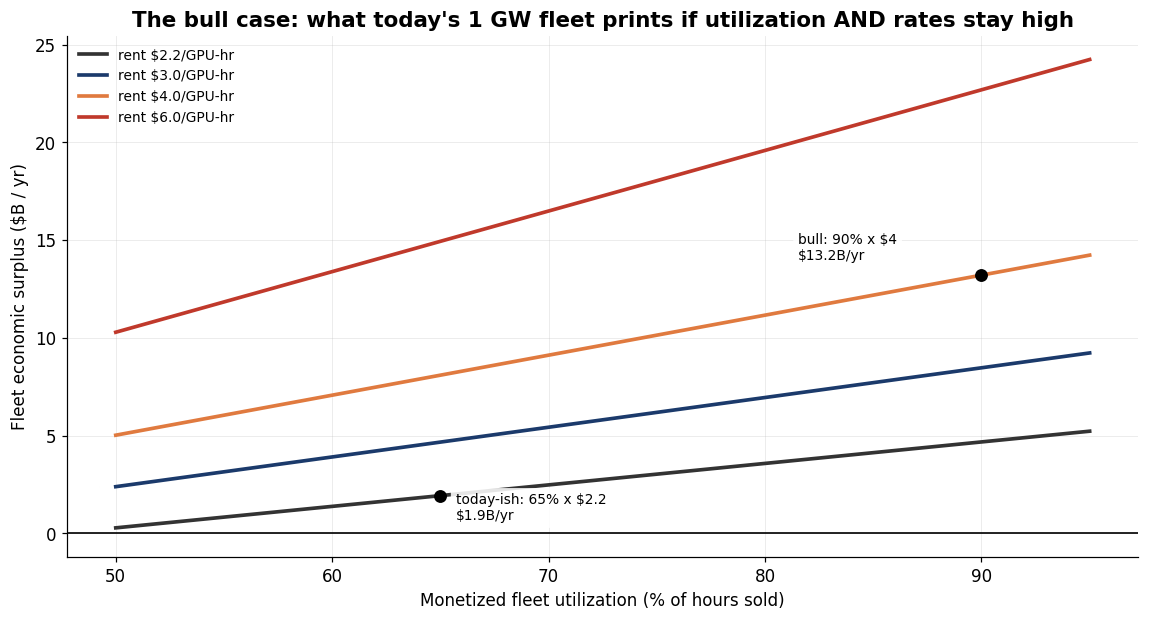

,gross rent ($B/yr),surplus after capital charge ($B/yr),FCF-ish ($B/yr),value per GW ($B @ WACC perpetuity),x10 GW ($B)
scenario,,,,,
today-ish (65% x $2.2),7.5,1.9,3.2,29.5,294.9
"high util, market rate (90% x $2.2)",10.4,4.7,6.0,54.5,544.5
bull (90% x $4),19.0,13.2,14.5,132.0,"1,319.8"
super-bull (90% x $6),28.4,22.7,24.0,218.1,"2,181.1"


Fleet gross book value (servers): $21.6B (601k GPUs x $36k)


In [12]:
# Steelman the bull: hold utilization AND rental rate high -- what does today's fleet print?
# Reuses gpu_costs() from the treadmill cell: dep + power + capital charge, 5-yr life base.
def fleet_surplus_b(util, rate, fleet_gpus=blended, life=5.0):
    """Fleet annual economic surplus ($B/yr): rent earned minus dep + power + capital charge."""
    rev  = fleet_gpus * util * 8760 * rate
    cost = fleet_gpus * sum(gpu_costs(FLEET_SYSTEM_USD_K, life, util))
    return (rev - cost) / 1e9

utils_b = np.linspace(0.50, 0.95, 50)
fig, ax = plt.subplots(figsize=(10.6, 5.8))
for rate, c in [(2.2, "#333"), (3.0, NAVY), (4.0, ORANGE), (6.0, PALETTE[4])]:
    ax.plot(utils_b * 100, [fleet_surplus_b(u, rate) for u in utils_b], color=c, lw=2.4,
            label=f"rent ${rate}/GPU-hr")
ax.axhline(0, color="black", lw=1.1)

# Markers: where the treadmill says we are vs where the bull needs us to be.
for (u, r, lbl, dx, dy) in [(0.65, 2.2, "today-ish: 65% x $2.2", 10, -16),
                            (0.90, 4.0, "bull: 90% x $4", -120, 10)]:
    s = fleet_surplus_b(u, r)
    ax.scatter([u * 100], [s], color="black", zorder=6, s=55)
    charts.annotate_clear(ax, f"{lbl}\n${s:.1f}B/yr", (u * 100, s),
                          textcoords="offset points", xytext=(dx, dy), fontsize=9)

ax.set_xlabel("Monetized fleet utilization (% of hours sold)")
ax.set_ylabel("Fleet economic surplus (\\$B / yr)")
ax.set_title("The bull case: what today's 1 GW fleet prints if utilization AND rates stay high")
charts.legend_panel(ax, fontsize=9, loc="upper left")
charts.finish(fig); charts.save(fig, "ai_bull_case", layout=False); plt.show()

# The same scenarios as a table, with naive scale-ups: value/GW as a perpetuity of the
# pre-capital-charge cash flow (rev - dep - power) at WACC, then x10 GW for the buildout bet.
rows = []
for name, u, r in [("today-ish (65% x $2.2)",          0.65, 2.2),
                   ("high util, market rate (90% x $2.2)", 0.90, 2.2),
                   ("bull (90% x $4)",                  0.90, 4.0),
                   ("super-bull (90% x $6)",            0.90, 6.0)]:
    rev  = blended * u * 8760 * r / 1e9
    d, p, cc = gpu_costs(FLEET_SYSTEM_USD_K, 5.0, u)
    fcf  = rev - blended * (d + p) / 1e9          # after dep (≈ sustaining re-buy) + power
    rows.append({"scenario": name,
                 "gross rent ($B/yr)": rev,
                 "surplus after capital charge ($B/yr)": fleet_surplus_b(u, r),
                 "FCF-ish ($B/yr)": fcf,
                 "value per GW ($B @ WACC perpetuity)": fcf / WACC_ASSUMED,
                 "x10 GW ($B)": 10 * fcf / WACC_ASSUMED})
bull = pd.DataFrame(rows).set_index("scenario")
display(fmt(bull, one=list(bull.columns)))
print(f"Fleet gross book value (servers): ${blended * FLEET_SYSTEM_USD_K / 1e6:,.1f}B "
      f"({blended/1e3:,.0f}k GPUs x ${FLEET_SYSTEM_USD_K}k)")

**Taken at face value, the bull case is spectacular — that's the point.** At 90% monetized
utilization and \$4/GPU-hr, today's ~\$22B fleet grosses ~\$19B a year and clears ~\$13B after
depreciation, power, and a full capital charge — it pays itself back in well under two years, and as a
perpetuity one gigawatt is worth on the order of \$100B+. Run the 10 GW buildout at those economics and
the AI segment alone justifies a trillion-dollar mark. **The arithmetic is not the problem.** The
problem is what the inputs require:

1. **Rates must double while supply explodes.** \$4–6/hr is where H100s rented in *2023*, before the
   flood; the observed path is ~\$2.2 and falling. The bull needs the price of compute to re-inflate
   *while* SpaceX (and Microsoft, and Google, and CoreWeave, and three sovereign funds) add gigawatts.
2. **90% must be *monetized* utilization** — hours actually sold. Every GPU-hour reserved for Grok
   training is busy but books \$0 (see the allocation asterisk above). You cannot simultaneously rent
   the fleet at 90% *and* run a frontier lab on it; the bull case and the AGI case compete for the
   same chips.
3. **The 5-year life has to hold at the frontier.** At \$4/hr the bull survives a 3-year
   obsolescence life comfortably (~\$11B/yr); at \$2.2 the surplus thins to ~\$2B — one price cut
   from zero. The faster Nvidia ships, the more the bull leans on rates rather than volume.

So the honest statement is: **the AI segment is a leveraged long position on the price of compute** —
fabulously profitable if utilization and rates both hold, a bonfire if either reverts. The scenario
notebooks price both branches; what the IPO does is pay for the good branch as if it were the only one.

## 6. Why "Adjusted EBITDA" is a fiction here

The S-1 reports a segment **Adjusted EBITDA** that went **+\$1,222M → +\$347M → –\$1,237M** (FY2023–25),
and it is tempting to read the –\$1.2B as "the real loss." It isn't — in *either* direction. Adjusted
EBITDA takes the \$(6,355)M operating loss and adds back \$5.1B of "non-cash / non-recurring" items to
arrive at –\$1.2B. **For this segment those add-backs are mostly real, recurring costs**, and the same
objection the Connectivity notebook makes about satellites applies here to silicon:

- **D&A is cost-of-revenue, not a bookkeeping entry.** §5 showed the depreciation is ~600k GPUs being
  *consumed* — not by wear, but by **obsolescence**: each NVIDIA generation makes the last one worth
  evicting. Those chips must be **rebought with cash** to keep the service competitive (that's the
  capex in §4). Adding depreciation back describes a company that gets to keep its GPUs for free.
- **SBC is real pay.** Stock comp went \$3M → \$16M → **\$1,063M** in two years — and on the Q1-2026
  run-rate it is **~46% of segment revenue**. It is non-cash only in the sense that it's settled in
  *shares* instead of dollars: it is the price of holding onto the scarce engineers who make Grok
  competitive, and it dilutes existing owners every year. Adding it back describes a company that gets
  its talent for free.

So we set Adjusted EBITDA aside and read the **operating loss** as the honest profitability number
(and, once capex is counted, the cash burn is far larger still). The chart below shows how much of the
"improvement" from operating loss to Adjusted EBITDA is just these two real costs.

,Operating income (loss),+ D&A (chips consumed),+ SBC (engineer pay),+ Restructuring,+ Impairment,"= ""Adjusted EBITDA"""
period,,,,,,
FY2023,"-3,973","1,180",3,237,"3,775","1,222"
FY2024,"-1,561","1,679",16,213,0,347
FY2025,"-6,355","3,568","1,063",487,0,"-1,237"
Q1-2026,"-2,469","1,493",378,-11,0,-609


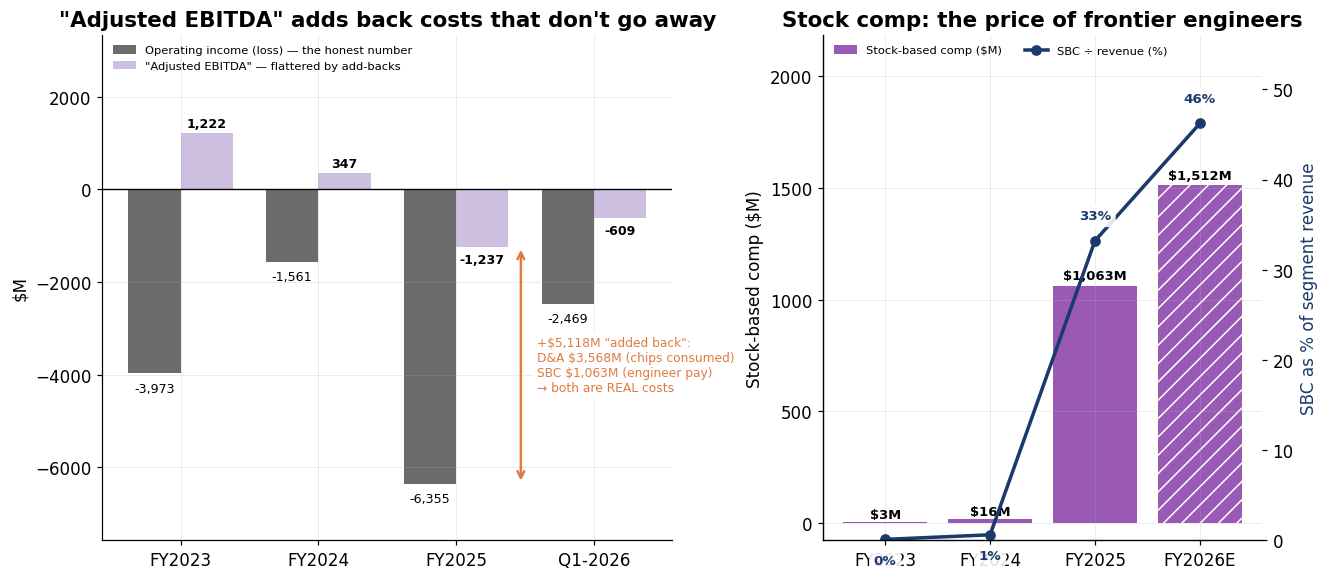

In [13]:
# What "Adjusted EBITDA" adds back -- and why most of it is real, recurring cost.
recon = pd.DataFrame({
    "Operating income (loss)": R.op_income,
    "+ D&A (chips consumed)":  R.da,
    "+ SBC (engineer pay)":    R.sbc,
    "+ Restructuring":         R.restructuring,
    "+ Impairment":            R.impairment,
})
recon['= "Adjusted EBITDA"'] = recon.sum(axis=1)
display(fmt(recon))

fig, (axL, axR) = plt.subplots(1, 2, figsize=(13.6, 5.6),
                               gridspec_kw={"width_ratios": [1.3, 1], "wspace": 0.3})

# --- Left: the honest operating loss vs the flattered "Adjusted EBITDA" ---
periods = PERIODS
x = np.arange(len(periods)); w = 0.38
op = R.op_income.values
eb = R.adj_ebitda_reported.values
axL.bar(x - w/2, op, w, color=GREY,      label="Operating income (loss) — the honest number")
axL.bar(x + w/2, eb, w, color="#cdbfe0", label='"Adjusted EBITDA" — flattered by add-backs')
for i in range(len(periods)):
    axL.annotate(f"{op[i]:,.0f}", (i - w/2, op[i]), textcoords="offset points",
                 xytext=(0, -12 if op[i] < 0 else 4), ha="center", fontsize=8.3)
    axL.annotate(f"{eb[i]:,.0f}", (i + w/2, eb[i]), textcoords="offset points",
                 xytext=(0, 4 if eb[i] >= 0 else -11), ha="center", fontsize=8.3, fontweight="bold")
i = periods.index("FY2025"); gx = i + w/2 + 0.28
axL.annotate("", xy=(gx, eb[i]), xytext=(gx, op[i]), arrowprops=dict(arrowstyle="<->", color=ORANGE, lw=1.6))
axL.text(gx + 0.12, (op[i] + eb[i]) / 2,
         f"+\\${eb[i]-op[i]:,.0f}M \"added back\":\nD&A \\${R.da['FY2025']:,.0f}M (chips consumed)\nSBC \\${R.sbc['FY2025']:,.0f}M (engineer pay)\n→ both are REAL costs",
         va="center", ha="left", fontsize=8.0, color=ORANGE,
         bbox=dict(boxstyle="round,pad=0.35", facecolor="white", alpha=0.9, edgecolor="none"))
axL.axhline(0, color="black", lw=0.9)
axL.set_xticks(x); axL.set_xticklabels(periods)
axL.set_ylabel("\\$M"); axL.set_ylim(-7200, 2200)
axL.set_title('"Adjusted EBITDA" adds back costs that don\'t go away')
charts.legend_panel(axL, fontsize=7.5)

# --- Right: the SBC bill -- essential talent cost, and a runaway share of revenue ---
sbc = to_chart("sbc"); rev = to_chart("revenue")
sbc_pct = np.array(sbc) / np.array(rev)
xb = np.arange(len(CHART_PERIODS))
bars = axR.bar(xb, sbc, color=PALETTE[3], label="Stock-based comp (\\$M)")
bars[-1].set_hatch("//"); bars[-1].set_edgecolor("white"); bars[-1].set_linewidth(0)
for i, v in enumerate(sbc):
    axR.text(i, v + (28 if v > 80 else 18), f"\\${v:,.0f}M", ha="center", fontsize=8.6, fontweight="bold")
axR.set_xticks(xb); axR.set_xticklabels(CHART_PERIODS)
axR.set_ylabel("Stock-based comp (\\$M)"); axR.set_ylim(0, 1950)
axR.set_title("Stock comp: the price of frontier engineers")
ax2 = axR.twinx()
ax2.plot(xb, sbc_pct * 100, marker="o", color=NAVY, lw=2.3, label="SBC ÷ revenue (%)")
for i, p in enumerate(sbc_pct):
    charts.annotate_clear(ax2, f"{p*100:.0f}%", (i, p*100), textcoords="offset points",
                 xytext=(0, 14 if p*100 > 5 else -16), ha="center", fontsize=8.8, color=NAVY, fontweight="bold")
ax2.set_ylabel("SBC as % of segment revenue", color=NAVY); ax2.set_ylim(0, 56); ax2.grid(False)
h1, l1 = axR.get_legend_handles_labels(); h2, l2 = ax2.get_legend_handles_labels()
charts.legend_twin_panel(axR, ax2, handles=h1 + h2, labels=l1 + l2, fontsize=7.5, ncol=2)
charts.pad_ylim(axL); charts.pad_ylim(axR); charts.finish_pair(fig, wspace=0.30); charts.save(fig, "ai_adjusted_ebitda", layout=False); plt.show()

Strip the add-backs and the picture is unambiguous. The FY2023 column looks least-bad on an EBITDA
basis (+\$1,222M) only because its \$(3,973)M operating loss is itself distorted by a one-off **\$3,775M
impairment** (the legacy-X writedown, §7); ignore that and the trend in the *honest* line is clean and
steep: an operating loss widening to **\$(6,355)M**, of which the market would like you to forgive \$5.1B
because it's "non-cash." But the D&A in that \$5.1B is GPUs aging out (§5), and the SBC is **~a third of
revenue in FY2025, ~46% on the Q1-2026 run-rate** — the cost of not losing the engineers to a competitor.
Both recur; neither is optional. Anyone valuing this segment off Adjusted EBITDA is valuing a company
that gets its **chips and its engineers for free**. We won't — the operating loss (and, in the DCF, the
cash after capex) is the number that counts.

## 7. Revenue quality & legacy baggage

Two footnotes worth flagging before we leave the descriptive pass:

- **Customer concentration.** The S-1's single largest customer (Customer A) is **20.9% of *total*
  company revenue** in FY2025 (down from 25.2% in FY2023) and "relates to all three segments." It is
  not broken out to AI, so we can't size the AI-specific dependence — but a one-fifth-of-the-company
  customer is a risk the report should name, especially as compute-leasing (a concentrated,
  enterprise-style revenue line) grows.
- **The FY2023 impairment.** AI carried a **\$3,775M impairment** in FY2023 — the writedown of goodwill
  / intangibles from the X acquisition. It doesn't recur, but it is the reason the segment's early
  GAAP numbers look apocalyptic, and a reminder of how much value the takeover vaporized before the AI
  story was grafted on.

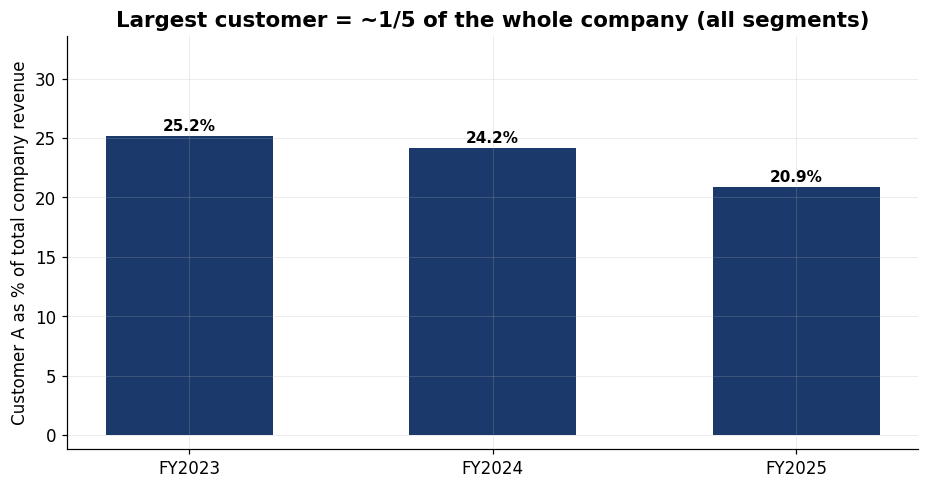

FY2023 AI impairment (legacy X writedown): $3,775M
FY2025 Customer A concentration: 20.9% of total revenue (was 25.2% in FY2023)


In [14]:
# Context table: customer concentration trend + the one-off impairment, pulled straight from the CSVs.
d = data.load_all()
om = d["other_metrics"]
conc = (om[om.metric == "Customer A revenue concentration"]
        .set_index("period_or_date")["value"].reindex(["FY2023", "FY2024", "FY2025"]))

fig, ax = plt.subplots(figsize=(8.6, 4.6))
xc = np.arange(len(conc))
bars = ax.bar(xc, conc.values, color=NAVY, width=0.55)
for i, v in enumerate(conc.values):
    ax.text(i, v + 0.4, f"{v:.1f}%", ha="center", fontsize=10, fontweight="bold")
ax.set_xticks(xc); ax.set_xticklabels(conc.index)
ax.set_ylabel("Customer A as % of total company revenue"); ax.set_ylim(0, 30)
ax.set_title("Largest customer = ~1/5 of the whole company (all segments)")
charts.finish(fig); charts.pad_ylim(ax)
charts.save(fig, "ai_customer_concentration", layout=False); plt.show()

print(f"FY2023 AI impairment (legacy X writedown): ${R.impairment['FY2023']:,.0f}M")
print(f"FY2025 Customer A concentration: {conc['FY2025']:.1f}% of total revenue (was {conc['FY2023']:.1f}% in FY2023)")

## Open threads → the next (scenario) notebook

This notebook described the AI segment as it stands. The forward model has to resolve the tensions it exposed:

1. **The crossover compounds.** Advertising (X) is shrinking and AI Solutions & Infrastructure is
   growing ~60–70%/yr. A forecast needs separate trajectories for the two — they are different
   businesses with different margins — not one blended "AI revenue" growth rate.
2. **Utilization is the master variable.** The §4 fleet is bought; whether it earns depends on how full
   it runs (own training + Grok inference + leased capacity to the likes of Anthropic). Model
   **revenue-per-GW** and a **utilization ramp**, not a top-line CAGR.
3. **When does it stop losing money?** Solve for operating (and, after capex, cash) break-even — *not*
   an Adjusted-EBITDA crossover (§6): the depreciation is a real cost, so the honest target is the point
   where the compute-revenue line clears the ~\$5–8B/yr the fleet costs to own (§5).
4. **R&D is the open-ended question.** Unlike Starship's *capitalizable* development invoice, model
   training R&D may not abate. Stress whether R&D stays at multiples of revenue or normalizes as Grok
   monetizes — and remember SBC (~⅓–½ of revenue) rides alongside it as real, recurring pay.
5. **Power is the ceiling, not just a cost.** Electricity is cheap (~\$0.3–0.4B, §3), but gigawatts of
   interconnect cap the fleet size, drive the obsolescence treadmill, and bound revenue (§5). Model the
   **GW glide path** as the hard constraint, with power *cost* scaling underneath it as utilization rises.
6. **Capex intensity must decay** for the segment to ever generate free cash flow. The DCF will live or
   die on the assumed glide path from ~4× revenue back toward a maintenance/refresh level.

*Data layer for all of the above: `analysis/ai_economics.py` (`AIModel.raw()`).*